# Markov Chain Monte Carlo (MCMC)

This notebook covers two foundational MCMC algorithms:

1. **Metropolis-Hastings** — general-purpose sampler using a proposal distribution and acceptance-rejection
2. **Gibbs Sampling** — special case where full conditional distributions are sampled directly

MCMC constructs a Markov chain whose stationary distribution is the desired target $\pi(x)$, allowing us to sample from complex, high-dimensional, or unnormalized distributions.

### Why MCMC?
When the target density $\pi(x)$ is known only up to a normalizing constant (e.g., Bayesian posterior $\pi(x) \propto p(y|x)p(x)$), direct sampling is impossible. MCMC solves this by exploring the state space via local moves.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Metropolis-Hastings Algorithm

Given a target density $\pi(x)$ (known up to a constant) and a proposal density $q(x'|x)$:

**Algorithm:**
1. Initialize $X_0$
2. For $t = 1, 2, \dots, N$:
   - Propose $Y \sim q(\cdot | X_{t-1})$
   - Compute acceptance probability:
     $$\alpha(X_{t-1}, Y) = \min\left(1, \frac{\pi(Y) \, q(X_{t-1}|Y)}{\pi(X_{t-1}) \, q(Y|X_{t-1})}\right)$$
   - Set $X_t = Y$ with probability $\alpha$, else $X_t = X_{t-1}$

For a **symmetric random walk proposal** $q(y|x) = \mathcal{N}(y; x, \sigma^2)$, the ratio simplifies to:
$$\alpha = \min\left(1, \frac{\pi(Y)}{\pi(X_{t-1})}\right)$$

**Key design choice:** The proposal scale $\sigma$ controls the trade-off between exploration (large jumps) and acceptance rate.


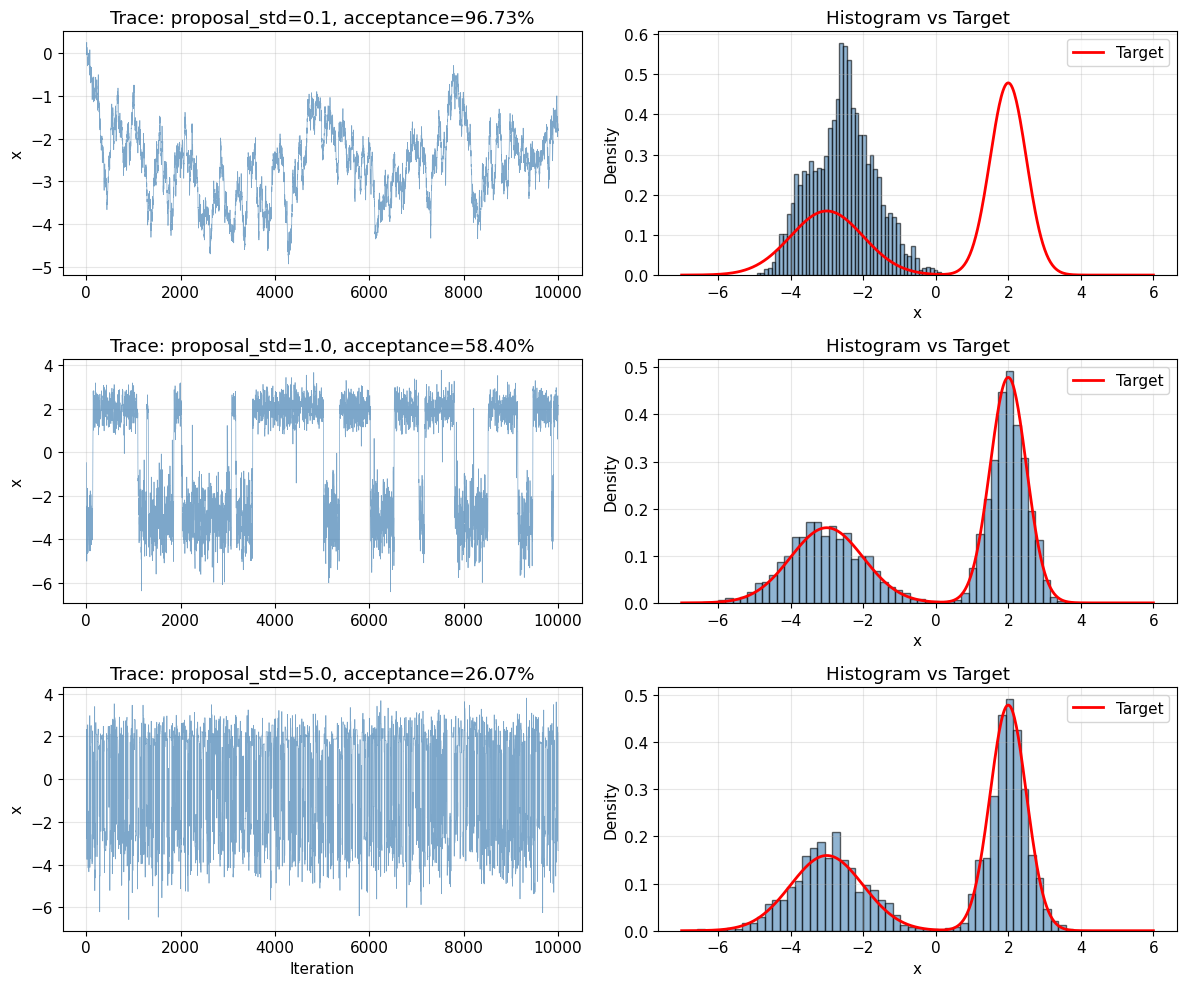

In [17]:
def norm_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def target_pdf(x):
    # Bimodal mixture: 0.4*N(-3, 1) + 0.6*N(2, 0.5^2)
    return 0.4 * norm_pdf(x, -3.0, 1.0) + 0.6 * norm_pdf(x, 2.0, 0.5)

def mh_sampler(n_samples, x0, proposal_std):
    samples = np.zeros(n_samples)
    x = x0
    accepted = 0
    for i in range(n_samples):
        y = np.random.normal(x, proposal_std)
        pi_y = target_pdf(y)
        pi_x = target_pdf(x)
        alpha = min(1.0, pi_y / pi_x) if pi_x > 0 else 1.0
        if np.random.rand() < alpha:
            x = y
            accepted += 1
        samples[i] = x
    return samples, accepted / n_samples

# Run MH with different proposal scales
n = 10000
x0 = 0.0
scales = [0.1, 1.0, 5.0]
results = []
for s in scales:
    samps, acc = mh_sampler(n, x0, s)
    results.append((samps, acc))

fig, axes = plt.subplots(len(scales), 2, figsize=(12, 10))
x_grid = np.linspace(-7, 6, 500)
true_density = target_pdf(x_grid)

for idx, (samps, acc) in enumerate(results):
    # Trace plot
    axes[idx, 0].plot(samps, lw=0.5, alpha=0.7, color='steelblue')
    axes[idx, 0].set_title('Trace: proposal_std={}, acceptance={:.2%}'.format(scales[idx], acc))
    axes[idx, 0].set_ylabel('x')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Histogram vs true density
    axes[idx, 1].hist(samps, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
    axes[idx, 1].plot(x_grid, true_density, 'r-', lw=2, label='Target')
    axes[idx, 1].set_title('Histogram vs Target')
    axes[idx, 1].set_xlabel('x')
    axes[idx, 1].set_ylabel('Density')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Iteration')
plt.tight_layout()
plt.show()


## 2. Gibbs Sampling

Gibbs sampling is a special case of Metropolis-Hastings where the proposal is the **exact full conditional distribution**, yielding an acceptance rate of **1**.

For a multivariate target $\pi(x_1, x_2, \dots, x_d)$:

**Algorithm:**
1. Initialize $\mathbf{x}^{(0)} = (x_1^{(0)}, \dots, x_d^{(0)})$
2. For $t = 1, 2, \dots, N$:
   - Sample $x_1^{(t)} \sim \pi(x_1 | x_2^{(t-1)}, \dots, x_d^{(t-1)})$
   - Sample $x_2^{(t)} \sim \pi(x_2 | x_1^{(t)}, x_3^{(t-1)}, \dots, x_d^{(t-1)})$
   - $\vdots$
   - Sample $x_d^{(t)} \sim \pi(x_d | x_1^{(t)}, \dots, x_{d-1}^{(t)})$

**Example:** Bivariate normal with correlation $\rho$:
- $X|Y=y \sim \mathcal{N}\left(\mu_x + \rho\frac{\sigma_x}{\sigma_y}(y-\mu_y), \; \sigma_x^2(1-\rho^2)\right)$
- $Y|X=x \sim \mathcal{N}\left(\mu_y + \rho\frac{\sigma_y}{\sigma_x}(x-\mu_x), \; \sigma_y^2(1-\rho^2)\right)$

Gibbs is efficient when conditionals are easy to sample, but can mix slowly if variables are highly correlated.


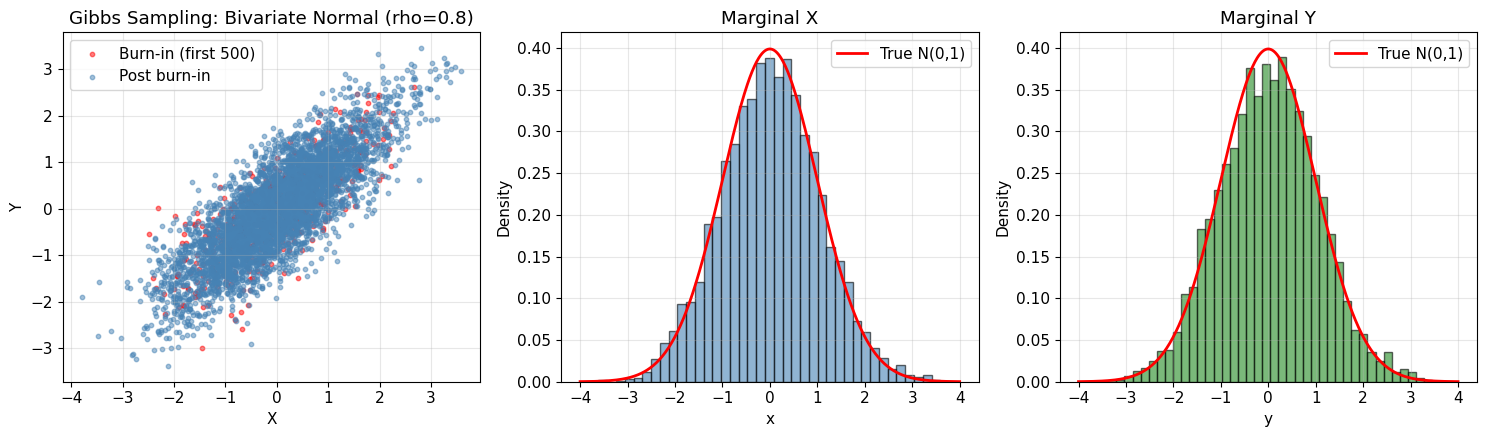

In [18]:
def gibbs_bivariate_normal(n_samples, mu, sigma, rho, x0, y0):
    samples = np.zeros((n_samples, 2))
    x, y = x0, y0
    var_cond_x = (sigma[0] ** 2) * (1.0 - rho ** 2)
    var_cond_y = (sigma[1] ** 2) * (1.0 - rho ** 2)
    std_x = np.sqrt(var_cond_x)
    std_y = np.sqrt(var_cond_y)
    
    for i in range(n_samples):
        mean_x = mu[0] + rho * (sigma[0] / sigma[1]) * (y - mu[1])
        x = np.random.normal(mean_x, std_x)
        mean_y = mu[1] + rho * (sigma[1] / sigma[0]) * (x - mu[0])
        y = np.random.normal(mean_y, std_y)
        samples[i, 0] = x
        samples[i, 1] = y
    return samples

mu = np.array([0.0, 0.0])
sigma = np.array([1.0, 1.0])
rho = 0.8
n_gibbs = 5000
gibbs_samples = gibbs_bivariate_normal(n_gibbs, mu, sigma, rho, 0.0, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Scatter plot with burn-in highlighted
axes[0].scatter(gibbs_samples[:500, 0], gibbs_samples[:500, 1], c='red', s=10, alpha=0.5, label='Burn-in (first 500)')
axes[0].scatter(gibbs_samples[500:, 0], gibbs_samples[500:, 1], c='steelblue', s=10, alpha=0.5, label='Post burn-in')
axes[0].set_title('Gibbs Sampling: Bivariate Normal (rho={})'.format(rho))
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Marginal X
axes[1].hist(gibbs_samples[:, 0], bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black')
x_fine = np.linspace(-4, 4, 500)
axes[1].plot(x_fine, norm_pdf(x_fine, 0.0, 1.0), 'r-', lw=2, label='True N(0,1)')
axes[1].set_title('Marginal X')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Marginal Y
axes[2].hist(gibbs_samples[:, 1], bins=40, density=True, alpha=0.6, color='forestgreen', edgecolor='black')
axes[2].plot(x_fine, norm_pdf(x_fine, 0.0, 1.0), 'r-', lw=2, label='True N(0,1)')
axes[2].set_title('Marginal Y')
axes[2].set_xlabel('y')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Diagnostics: Burn-in, Autocorrelation, and Effective Sample Size

MCMC samples are **correlated**, unlike i.i.d. Monte Carlo. Key diagnostics:

- **Burn-in**: The initial transient before the chain reaches stationarity. Discard the first $B$ samples.
- **Autocorrelation Function (ACF)**: Measures dependence across iterations. Slow decay indicates poor mixing.
- **Effective Sample Size (ESS)**:
  $$\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{\infty}\rho_k}$$

  where $\rho_k$ is the autocorrelation at lag $k$. ESS tells you how many i.i.d. samples your correlated chain is "worth."

**Practical rules:**
- Acceptance rate for random-walk MH: target 20-50% (optimal ~23% in high dimensions, ~44% in 1D)
- If ACF is still large at lag 20+, consider thinning or a better proposal
- 

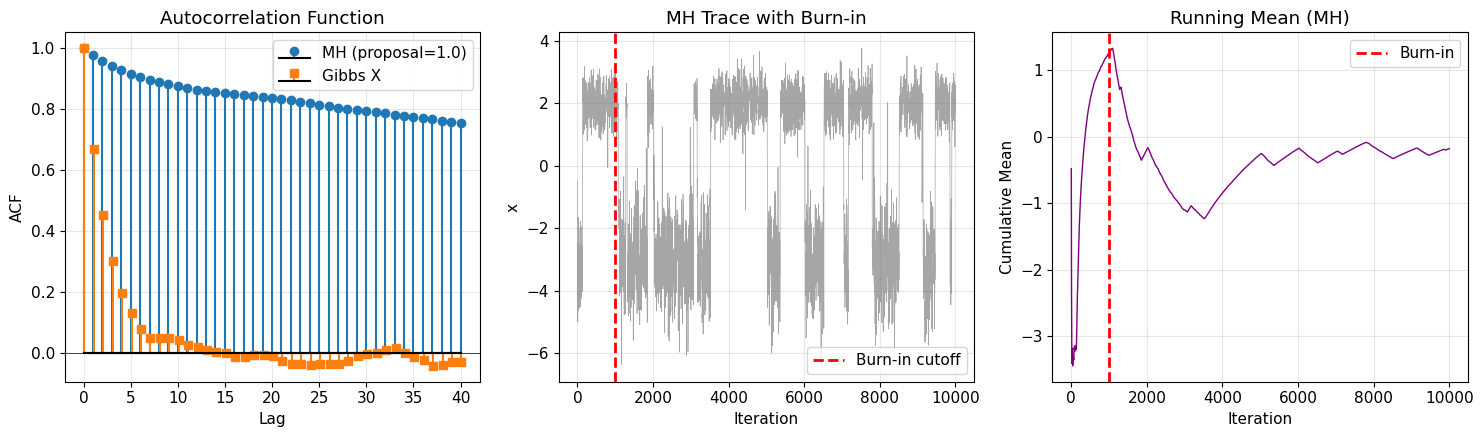

Diagnostics (post burn-in):
----------------------------------------
MH:     N = 9000, ESS = 132.2, ratio = 68.08
Gibbs X: N = 4500, ESS = 864.9, ratio = 5.20

Acceptance rates:
  proposal_std=0.1: 96.73%
  proposal_std=1.0: 58.40%
  proposal_std=5.0: 26.07%


In [19]:
def autocorr(x, max_lags=40):
    x = x - np.mean(x)
    n = len(x)
    c = np.correlate(x, x, mode='full')
    c = c[n - 1:]
    if c[0] == 0:
        return np.zeros(max_lags + 1)
    return c[:max_lags + 1] / c[0]

def ess_from_acf(x, max_lags=40):
    acf_vals = autocorr(x, max_lags)
    pos_acf = acf_vals[1:]
    pos_acf = pos_acf[pos_acf > 0]
    return len(x) / (1.0 + 2.0 * np.sum(pos_acf))

# Use the well-tuned MH chain (proposal_std=1.0)
samps_mh = results[1][0]
burn_mh = 1000
samps_mh_post = samps_mh[burn_mh:]

# Gibbs post burn-in
burn_gibbs = 500
samps_gibbs_post = gibbs_samples[burn_gibbs:]

lags = np.arange(41)
acf_mh = autocorr(samps_mh_post, 40)
acf_gibbs_x = autocorr(samps_gibbs_post[:, 0], 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ACF comparison
axes[0].stem(lags, acf_mh, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='MH (proposal=1.0)')
axes[0].stem(lags + 0.1, acf_gibbs_x, linefmt='C1-', markerfmt='C1s', basefmt='k-', label='Gibbs X')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Autocorrelation Function')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Burn-in visualization
axes[1].plot(samps_mh, lw=0.5, alpha=0.7, color='gray')
axes[1].axvline(burn_mh, color='red', linestyle='--', lw=2, label='Burn-in cutoff')
axes[1].set_title('MH Trace with Burn-in')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('x')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Running mean convergence
running_mean = np.cumsum(samps_mh) / np.arange(1, len(samps_mh) + 1)
axes[2].plot(running_mean, lw=1.0, color='purple')
axes[2].axvline(burn_mh, color='red', linestyle='--', lw=2, label='Burn-in')
axes[2].set_title('Running Mean (MH)')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Cumulative Mean')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ess_mh = ess_from_acf(samps_mh_post)
ess_gibbs = ess_from_acf(samps_gibbs_post[:, 0])

print("Diagnostics (post burn-in):")
print("-" * 40)
print("MH:     N = {}, ESS = {:.1f}, ratio = {:.2f}".format(len(samps_mh_post), ess_mh, len(samps_mh_post)/ess_mh))
print("Gibbs X: N = {}, ESS = {:.1f}, ratio = {:.2f}".format(len(samps_gibbs_post), ess_gibbs, len(samps_gibbs_post)/ess_gibbs))
print("\nAcceptance rates:")
for idx, s in enumerate(scales):
    print("  proposal_std={}: {:.2%}".format(s, results[idx][1]))


## 4. Summary and Practical Guidance

| Aspect | Metropolis-Hastings | Gibbs Sampling |
|--------|---------------------|----------------|
| **Requirements** | Target evaluable (unnormalized OK) | Full conditionals must be sampleable |
| **Acceptance** | < 100% (tune proposal) | Always 100% |
| **Best for** | General targets, Bayesian posteriors | Hierarchical models, conjugate priors |
| **Pitfalls** | Poor proposal -> slow mixing; multi-modal traps | Strong correlation -> slow exploration |
| **Tuning** | Proposal scale, adaptation | None (if conditionals known) |

### Key Takeaways
1. **Burn-in is essential** — always discard the initial transient.
2. **Thinning** (keeping every $k$-th sample) reduces storage and autocorrelation but does not increase ESS.
3. **Multiple chains** from dispersed starts help assess convergence (Gelman-Rubin $\hat{R}$).
4. For complex targets, use **adaptive MH** (e.g., NUTS, Hamiltonian Monte Carlo) instead of random-walk proposals.

MCMC is the workhorse of modern Bayesian computation, enabling inference in models where no closed-form solution exists.
